In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [4]:
file_path = r"C:\Users\Max\Desktop\Dataset for Data Analytics.xlsx"
df = pd.read_excel(file_path)
print(df.head())

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREESHIP  

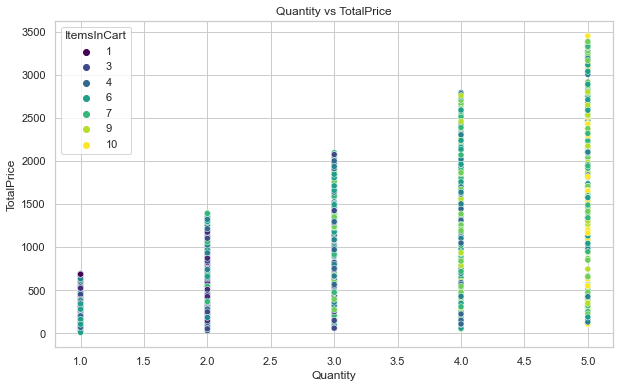

In [10]:
sns.scatterplot(data=df, x="Quantity", y="TotalPrice", hue="ItemsInCart", palette="viridis")
plt.title("Quantity vs TotalPrice")
plt.show()

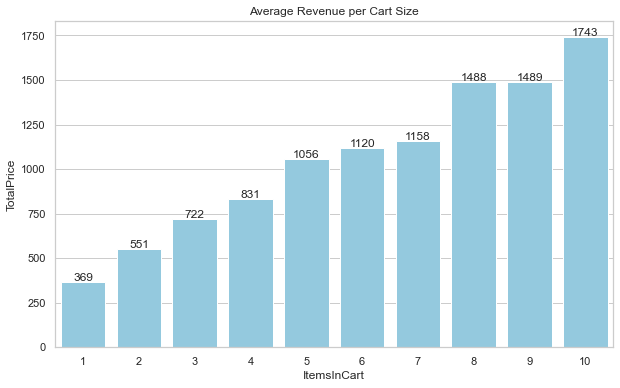

In [11]:
cart_revenue = df.groupby("ItemsInCart")["TotalPrice"].mean().reset_index()

sns.barplot(data=cart_revenue, x="ItemsInCart", y="TotalPrice", color="skyblue")
for index, row in cart_revenue.iterrows():
    plt.text(index, row.TotalPrice + 5, f"{row.TotalPrice:.0f}", ha="center")
plt.title("Average Revenue per Cart Size")
plt.show()


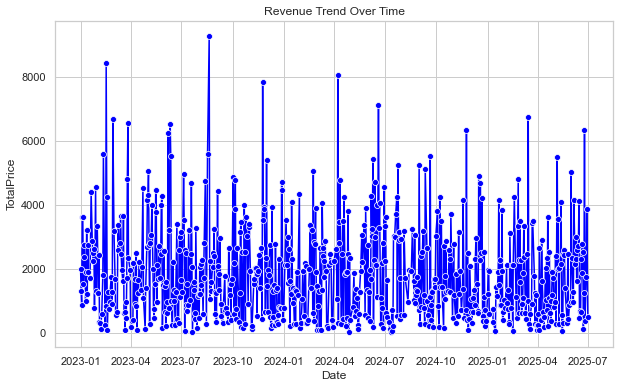

In [12]:
if "Date" in df.columns:
    revenue_trend = df.groupby("Date")["TotalPrice"].sum().reset_index()
    sns.lineplot(data=revenue_trend, x="Date", y="TotalPrice", marker="o", color="blue")
    plt.title("Revenue Trend Over Time")
    plt.show()


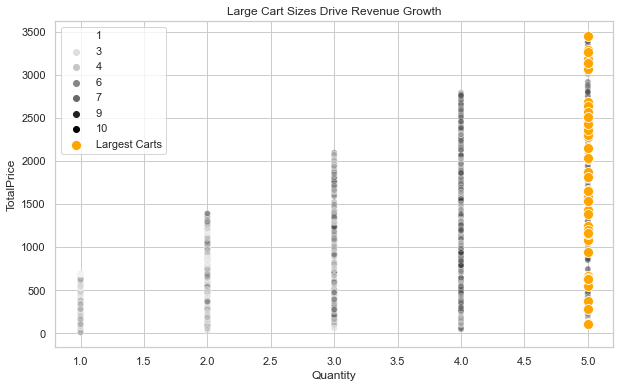

In [13]:
highlight = df[df["ItemsInCart"] >= df["ItemsInCart"].max()]

sns.scatterplot(data=df, x="Quantity", y="TotalPrice", hue="ItemsInCart", palette="Greys", alpha=0.5)
sns.scatterplot(data=highlight, x="Quantity", y="TotalPrice", color="orange", s=100, label="Largest Carts")
plt.title("Large Cart Sizes Drive Revenue Growth")
plt.legend()
plt.show()


In [14]:
baseline = df["TotalPrice"].mean()
complication = df[df["Quantity"] > df["Quantity"].median()]["TotalPrice"].mean()

print(f"Situation: Average order revenue is {baseline:.0f}.")
print(f"Complication: Orders with above‑median quantities generate {complication:.0f}, a significant uplift.")
print("Resolution: Incentivize larger cart sizes to maximize revenue.")


Situation: Average order revenue is 1054.
Complication: Orders with above‑median quantities generate 1598, a significant uplift.
Resolution: Incentivize larger cart sizes to maximize revenue.


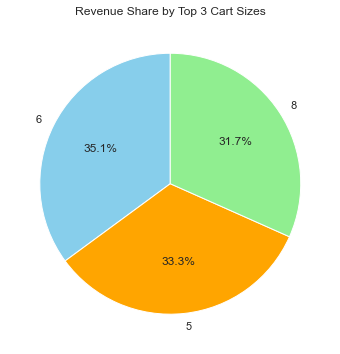

In [16]:
cart_share = df.groupby("ItemsInCart")["TotalPrice"].sum()

top_carts = cart_share.sort_values(ascending=False).head(3)

plt.pie(top_carts, labels=top_carts.index, autopct="%1.1f%%", startangle=90, colors=["skyblue","orange","lightgreen"])
plt.title("Revenue Share by Top 3 Cart Sizes")
plt.show()
